# Sustainable Development Goal 6: Clean Water and Sanitation

This Jupyter Notebook focuses on the development and preparation of the SDG 6 Sub-Index, which relates to the United Nations Sustainable Development Goal 6: Clean Water and Sanitation.

The purpose of this notebook is to import, inspect, clean, and prepare datasets associated with water and sanitation indicators for use in a larger composite indicator project. The processed data will later contribute towards calculating a comparative SDG readiness score across countries.

The following datasets are obtained through: https://unstats.un.org/sdgs/dataportal/ 

**Disclaimer: This dataset has already been standardised by the UN SDG database, therefore some common data cleaning steps such as formatting corrections, unit conversions, and major transformations were not required. The cleaning process mainly focused on handling missing values, identifying duplicates, selecting relevant indicators and preparing the data for analysis.**

### 1.1 Import Data

In [190]:
# Import pandas
import pandas as pd

# Load datasets
stress_df = pd.read_excel("ER_H2O_STRESS.xlsx")
drinking_df = pd.read_excel("SH_H2O_SAFE.xlsx")
handwash_df = pd.read_excel("SH_SAN_HNDWSH.xlsx")

# Display first 5 rows of each dataframe
print("Freshwater Stress Dataset:")
display(stress_df.head())

print("\nDrinking Water Dataset:")
display(drinking_df.head())

print("\nHandwashing Facilities Dataset:")
display(handwash_df.head())

PermissionError: [Errno 13] Permission denied: 'ER_H2O_STRESS.xlsx'

#### 1.2 Meaning of Datasets 

- stress_df : Level of water stress: freshwater withdrawal as a proportion of available freshwater resources (%) ER_H2O_STRESS.xlsx
- drinking_df : Proportion of population using safely managed drinking water services, by urban/rural (%) SH_H2O_SAFE.xlsx
- handwash_df : Proportion of population with basic handwashing facilities on premises, by urban/rural (%) SH_SAN_HNDWSH.xlsx

### 2.1 Select Columns

In [ ]:
# Select columns for each dataset

# Years
years_2000_2023 = [str(year) for year in range(2000, 2024)]
years_2000_2024 = [str(year) for year in range(2000, 2025)]

# stress_df columns
stress_df.columns = stress_df.columns.str.strip()
stress_df = stress_df[['GeoAreaName', 'Activity', 'Observation Status'] + years_2000_2023]

# drinking_df columns
drinking_df = drinking_df[['GeoAreaName', 'Location'] + years_2000_2024]

# handwash_df columns
handwash_df = handwash_df[['GeoAreaName', 'Location'] + years_2000_2024]

# Display first 5 rows
print("Stress Dataset:")
display(stress_df.head())

print("\nDrinking Water Dataset:")
display(drinking_df.head())

print("\nHandwashing Dataset:")
display(handwash_df.head())

Stress Dataset:


,GeoAreaName,Activity,Observation Status,2000,2001,2002,2003,2004,2005,2006,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Afghanistan,INDUSTRIES,E,0.35,0.37,0.39,0.41,0.43,0.46,0.46,...,0.46,0.46,0.46,0.46,0.46,0.46,0.46,0.46,0.46,0.46
1,Afghanistan,ISIC4_A01_A0210_A0322,E,53.99,53.95,53.90,53.85,53.80,53.75,53.75,...,53.75,53.75,53.75,53.75,53.75,53.75,53.75,53.75,53.75,53.75
2,Afghanistan,ISIC4_GTT,E,0.42,0.44,0.47,0.49,0.52,0.55,0.55,...,0.55,0.55,0.55,0.55,0.55,0.55,0.55,0.55,0.55,0.55
3,Afghanistan,TOTAL,I,54.76,54.76,54.76,54.76,54.76,54.76,54.76,...,54.76,54.76,54.76,54.76,54.76,54.76,54.76,54.76,54.76,54.76
4,Albania,INDUSTRIES,E,1.37,1.37,1.38,1.38,1.39,1.39,1.33,...,0.84,0.78,0.87,0.66,0.59,1.21,0.10,0.06,0.07,0.07



Drinking Water Dataset:


,GeoAreaName,Location,2000,2001,2002,2003,2004,2005,2006,2007,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,ALLAREA,11.483052,11.495201,12.298100,13.100750,13.910267,14.726554,15.542417,16.650249,...,23.391308,24.222923,25.055178,25.888214,26.721855,27.555935,28.390680,29.225822,29.907448,30.554722
1,Afghanistan,RURAL,8.535748,8.535748,9.356640,10.177532,10.998424,11.819316,12.640207,13.841233,...,20.725376,21.574842,22.424307,23.273773,24.123240,24.972704,25.822170,26.671635,27.521101,28.370565
2,Afghanistan,URBAN,21.885258,21.885258,22.570154,23.255051,23.939945,24.624842,25.309738,25.994635,...,31.473801,32.158695,32.843594,33.528488,34.213383,34.898281,35.583176,36.268070,36.381409,36.381409
3,Albania,ALLAREA,49.138321,49.081200,48.984764,48.885441,50.717678,52.578335,54.467083,56.383842,...,70.591972,70.616508,70.636940,70.653351,70.665855,70.674538,70.705795,70.736069,70.765396,70.793739
4,Algeria,ALLAREA,69.493111,69.988586,70.470352,70.937912,71.391342,71.830215,72.255196,72.665878,...,75.409615,74.781487,74.068275,73.326546,72.218796,70.525162,68.839241,68.904511,68.967865,69.029182



Handwashing Dataset:


,GeoAreaName,Location,2000,2001,2002,2003,2004,2005,2006,2007,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,ALLAREA,NaN,NaN,NaN,NaN,NaN,35.343674,35.424873,35.506866,...,42.372295,43.461876,44.546391,45.625549,46.698284,47.763611,48.821293,49.870121,50.909424,51.938343
1,Afghanistan,RURAL,NaN,NaN,NaN,NaN,NaN,26.307232,26.307232,26.307232,...,35.333042,36.837345,38.341648,39.845947,41.350250,42.854553,44.358856,45.863155,47.367458,48.871761
2,Afghanistan,URBAN,NaN,NaN,NaN,NaN,NaN,66.110092,66.110092,66.110092,...,63.713688,63.314285,62.914886,62.515484,62.116085,61.716686,61.317284,60.917885,60.518482,60.119083
3,Algeria,ALLAREA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.913795,...,83.980202,84.120506,84.254959,84.383972,84.507561,84.625984,84.739372,84.804092,84.866920,84.927719
4,Algeria,RURAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72.832428,...,73.832764,74.082848,74.332932,74.583008,74.833092,75.083176,75.333260,75.333260,75.333260,75.333260


#### 2.2 Selection of Columns

At this stage, only the variables required for the SDG 6 sub-index analysis are retained from each dataset.

The selection keeps:
- all countries available within the datasets,
- identifying columns such as `GeoAreaName`, `Observation Status`, `Location`, or `Activity`,
- yearly indicator values beginning from 2000 up to the most recent year available within each dataset.

### 3.1 Dealing with Duplicates

Duplicates will be dealt in 4.1 Check & Handling of Missing Values (Imputation of Missing Data)

#### stress_df

During the initial inspection of the dataset, multiple rows were identified for the same country and year. These are not true duplicates, but occur because the dataset is separated by both activity category and observation status.

Countries are repeated across different activity categories:
- `INDUSTRIES` (overall industry)
- `ISIC4_GTT` (tertiary/services sector)
- `ISIC4_A01_A0210_A0322` (primary sector)
- `TOTAL` which represents the sum across all sectors

These categories represent freshwater stress measurements across different economic sectors.

Countries are also repeated across different observation statuses (`A`, `E`, `I`, and `O`). These statuses indicate that the values were reported, estimated, or produced by different statistical or governing bodies.

As a result, the same country and year may appear multiple times with slightly different measurements or missing values depending on the observation source.

#### drinking_df

In this dataset, countries may also appear multiple times per year. These are not true duplicates, as the data is divided by location categories:
- `ALLAREA` (combined total of rural and urban areas)
- `RURAL`
- `URBAN`

Each category represents a different measurement of access to drinking water based on population location. Therefore, these rows were treated as separate observations rather than removed as duplicates.

#### handwash_df

The handwash_df dataset follows the same structure as drinking_df, where countries may appear multiple times per year due to different location categories:
- `ALLAREA`
- `RURAL`
- `URBAN`

These represent separate measurements rather than true duplicates, so they were retained during the cleaning process.

### 4.1 Check & Handling of Missing Values (Imputation of Missing Data)

#### Stress Dataset

In [ ]:
# Check for blank or NaN values

blank_or_nan = stress_df.isnull().sum() + (stress_df == '').sum()

print("Blank or NaN Values Per Column:")
display(blank_or_nan[blank_or_nan > 0])

Blank or NaN Values Per Column:


2000    694
2001    681
2002    669
2003    665
2004    660
2005    649
2006    638
2007    627
2008    614
2009    614
2010    607
2011    607
2012    590
2013    588
2014    585
2015    585
2016    583
2017    583
2018    583
2019    583
2020    583
2021    583
2022    583
2023    583
dtype: int64

The freshwater stress dataset contains multiple rows for each country and year because the data is divided by both economic activity and observation status.

The activity categories include:
- `INDUSTRIES` (overall industry)
- `ISIC4_GTT` (tertiary/services sector)
- `ISIC4_A01_A0210_A0322` (primary sector)
- `TOTAL` which represents the sum across all sectors

The dataset also includes different observation statuses (`A`, `E`, `I`, and `O`), which indicate that the values were collected or estimated by different organisations or statistical bodies. As a result, some rows may contain missing values while the same country and year are available under another observation status.

For this analysis, only the `TOTAL` activity values will be used, as they already combine the measurements from all sectors into a single freshwater stress value per country and year.

In [ ]:
# Clean column names
stress_df.columns = stress_df.columns.astype(str).str.strip()

# Keep only rows where Activity is TOTAL
stress_df = stress_df[
    stress_df['Activity'].astype(str).str.upper().str.strip() == 'TOTAL'
].copy()

# Keep only country name and year columns
years_2000_2023 = [str(year) for year in range(2000, 2024)]
stress_df = stress_df[['GeoAreaName'] + years_2000_2023]
stress_df[years_2000_2023] = stress_df[years_2000_2023].apply(
    pd.to_numeric,
    errors='coerce'
)

# Merge repeated countries by taking first non-missing value
stress_df = (
    stress_df
    .groupby('GeoAreaName', as_index=False)
    .first()
)

# From the new derived stress_df check missing values per country
missing_per_country = stress_df.isnull().sum(axis=1)

# Keep only countries with missing values
missing_per_country = missing_per_country[missing_per_country > 0]

missing_values_df = pd.DataFrame({
    'GeoAreaName': stress_df.loc[missing_per_country.index, 'GeoAreaName'],
    'Missing Values': missing_per_country.values
})

display(missing_values_df)

,GeoAreaName,Missing Values
3,Andorra,7
13,Bangladesh,8
19,Bermuda,5
20,Bhutan,8
29,Cabo Verde,1
30,Cambodia,6
44,Costa Rica,5
45,Croatia,2
66,Ethiopia,2
72,French Guiana,12


In [ ]:
# Remove countries with more than 5 missing values
stress_df = stress_df[
    stress_df.isnull().sum(axis=1) <= 5
].copy()

# Set country name as index temporarily
stress_df = stress_df.set_index('GeoAreaName')

# Impute missing values using neighbouring year trends and country mean
for country in stress_df.index:

    row = stress_df.loc[country]

    for year in years_2000_2023:

        # If value is missing
        if pd.isna(row[year]):

            year_int = int(year)

            prev_year = str(year_int - 1)
            next_year = str(year_int + 1)

            estimates = []

            # Previous year value
            if prev_year in stress_df.columns and not pd.isna(row.get(prev_year)):
                estimates.append(row[prev_year])

            # Next year value
            if next_year in stress_df.columns and not pd.isna(row.get(next_year)):
                estimates.append(row[next_year])

            # Country mean
            country_mean = row.mean(skipna=True)

            # If neighbouring years exist, average them with country mean
            if len(estimates) > 0:
                imputed_value = (sum(estimates) + country_mean) / (len(estimates) + 1)
            else:
                imputed_value = country_mean

            # Fill missing value
            stress_df.at[country, year] = imputed_value

stress_df = stress_df.reset_index()

# Check for remaining missing values after imputation
remaining_missing = stress_df.isnull().sum(axis=1)

# Keep only countries with missing values
remaining_missing = remaining_missing[remaining_missing > 0]

# Total remaining missing values
total_remaining_missing = stress_df.isnull().sum().sum()

print("Final missing values:", total_remaining_missing)
print("Countries remaining:", stress_df['GeoAreaName'].nunique())

Final missing values: 0
Countries remaining: 198


How `stress_df` is cleaned:

Countries with more than 5 missing yearly observations between 2000 and 2023 were removed from the dataset to improve the reliability of the analysis and reduce biased imputation.

After filtering, missing values were estimated using a trend-based imputation approach. For each missing year:
- the previous year's value and next year's value were checked
- any available neighbouring values were collected
- and the overall average freshwater stress value for that country was calculated

If neighbouring year values were available, the missing value was estimated by averaging:
- the neighbouring year values,
- together with the country's overall mean.

This helps preserve the general trend of increases or decreases over time while also keeping the estimated value consistent with the country's historical pattern.

If neighbouring year values were unavailable, the country's average value was used instead.

#### Drinking Dataset

In [ ]:
# Clean column names
drinking_df.columns = drinking_df.columns.astype(str).str.strip()

# Keep only rows where Location is ALLAREA
drinking_df = drinking_df[
    drinking_df['Location'].astype(str).str.upper().str.strip() == 'ALLAREA'
].copy()

# Keep only country name and year columns
years_2000_2024 = [str(year) for year in range(2000, 2025)]
drinking_df = drinking_df[['GeoAreaName'] + years_2000_2024]
drinking_df[years_2000_2024] = drinking_df[years_2000_2024].apply(
    pd.to_numeric,
    errors='coerce'
)

# From the new derived drinking_df Check missing values per country
missing_per_country = drinking_df.isnull().sum(axis=1)

# Keep only countries with missing values
missing_per_country = missing_per_country[missing_per_country > 0]

missing_values_df = pd.DataFrame({
    'GeoAreaName': drinking_df.loc[missing_per_country.index, 'GeoAreaName'],
    'Missing Values': missing_per_country.values
})

display(missing_values_df)

,GeoAreaName,Missing Values
69,Congo,3
85,Democratic People's Republic of Korea,1
129,French Guiana,1
146,Grenada,7
147,Guadeloupe,1
180,Isle of Man,9
186,Jersey,7
229,Mayotte,7
242,Montenegro,6
273,Northern America,5


In [ ]:
# Remove countries with more than 5 missing values
drinking_df = drinking_df[
    drinking_df.isnull().sum(axis=1) <= 5
].copy()

# Set country name as index temporarily
drinking_df = drinking_df.set_index('GeoAreaName')

# Impute missing values using neighbouring year trends and country mean
for country in drinking_df.index:

    row = drinking_df.loc[country]

    for year in years_2000_2024:

        # If value is missing
        if pd.isna(row[year]):

            year_int = int(year)

            prev_year = str(year_int - 1)
            next_year = str(year_int + 1)

            estimates = []

            # Previous year value
            if prev_year in drinking_df.columns and not pd.isna(row.get(prev_year)):
                estimates.append(row[prev_year])

            # Next year value
            if next_year in drinking_df.columns and not pd.isna(row.get(next_year)):
                estimates.append(row[next_year])

            # Country mean
            country_mean = row.mean(skipna=True)

            # If neighbouring years exist, average them with country mean
            if len(estimates) > 0:
                imputed_value = (sum(estimates) + country_mean) / (len(estimates) + 1)
            else:
                imputed_value = country_mean

            # Fill missing value
            drinking_df.at[country, year] = imputed_value

drinking_df = drinking_df.reset_index()


# Check for remaining missing values after imputation
remaining_missing = drinking_df.isnull().sum(axis=1)

# Keep only countries with missing values
remaining_missing = remaining_missing[remaining_missing > 0]

# Total remaining missing values
total_remaining_missing = drinking_df.isnull().sum().sum()

print("Final missing values:", total_remaining_missing)
print("Countries remaining:", drinking_df['GeoAreaName'].nunique())

Final missing values: 0
Countries remaining: 187


Cleaning `drinking_df`

The `drinking_df` dataset was cleaned using the same process as `stress_df`. Countries with more than 5 missing yearly observations between 2000 and 2023 were removed, while remaining missing values were estimated using neighbouring year trends together with each country's overall mean to preserve the general time-series pattern.

#### Handwash Dataset

In [ ]:
# Clean column names
handwash_df.columns = handwash_df.columns.astype(str).str.strip()

# Keep only rows where Location is ALLAREA
handwash_df = handwash_df[
    handwash_df['Location'].astype(str).str.upper().str.strip() == 'ALLAREA'
].copy()

# Keep only country name and year columns
years_2000_2024 = [str(year) for year in range(2000, 2025)]
handwash_df = handwash_df[['GeoAreaName'] + years_2000_2024]
handwash_df[years_2000_2024] = handwash_df[years_2000_2024].apply(
    pd.to_numeric,
    errors='coerce'
)
display(handwash_df.head())

# Check missing values per country
missing_per_country = handwash_df.isnull().sum(axis=1)

# Keep only countries with missing values
missing_per_country = missing_per_country[missing_per_country > 0]

# Create dataframe for display
missing_values_df = pd.DataFrame({
    'GeoAreaName': handwash_df.loc[missing_per_country.index, 'GeoAreaName'],
    'Missing Values': missing_per_country.values
})

display(missing_values_df)

,GeoAreaName,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,NaN,NaN,NaN,NaN,NaN,35.343674,35.424873,35.506866,35.589260,...,42.372295,43.461876,44.546391,45.625549,46.698284,47.763611,48.821293,49.870121,50.909424,51.938343
3,Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.913795,83.029343,...,83.980202,84.120506,84.254959,84.383972,84.507561,84.625984,84.739372,84.804092,84.866920,84.927719
6,Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,35.437260,35.617798,35.794994,35.968342,36.138603,36.305019,36.468090,36.627567,36.783451,36.935738
9,Armenia,83.24601,83.814072,84.421776,85.044922,85.670441,86.298126,86.928421,87.560898,88.195953,...,92.720802,93.381004,94.042938,94.395912,94.400497,94.406654,94.414368,94.423660,NaN,NaN
12,Aruba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,98.607246,98.607246,98.607246,98.607246,98.607246,98.607246,98.607246,98.607246,98.607246,98.607246


,GeoAreaName,Missing Values
0,Afghanistan,5
3,Algeria,7
6,Angola,10
9,Armenia,2
12,Aruba,13
...,...,...
403,Western Asia,16
405,World,13
408,Yemen,7
411,Zambia,8


In [ ]:
# Number of year columns
total_years = len(years_2000_2024)

# Calculate missing values per country
handwash_df['Missing_Count'] = handwash_df[years_2000_2024].isnull().sum(axis=1)

# Calculate missing percentage per country
handwash_df['Missing_Percentage'] = (
    handwash_df['Missing_Count'] / total_years
) * 100

# Remove countries with more than 50% missing values
handwash_df = handwash_df[
    handwash_df['Missing_Percentage'] <= 50
].copy()

# Drop calculation columns before imputation
handwash_df = handwash_df.drop(
    columns=['Missing_Count', 'Missing_Percentage']
)

# Set country name as index temporarily
handwash_df = handwash_df.set_index('GeoAreaName')

# Fill internal missing gaps using linear interpolation
handwash_df[years_2000_2024] = handwash_df[years_2000_2024].interpolate(
    axis=1,
    method='linear',
    limit_area='inside'
)

# Fill short missing values at the beginning
handwash_df[years_2000_2024] = handwash_df[years_2000_2024].bfill(
    axis=1
)

# Fill short missing values at the end
handwash_df[years_2000_2024] = handwash_df[years_2000_2024].ffill(
    axis=1
)

handwash_df = handwash_df.reset_index()

# Check final missing values
remaining_missing_df = handwash_df[years_2000_2024].isnull().sum().sum()

print("Final missing values:", remaining_missing_df)
print("Countries remaining:", handwash_df['GeoAreaName'].nunique())

Final missing values: 0
Countries remaining: 90


Cleaning `handwash_df`

Unlike previous datasets I cleaned where countries with more than 5 missing yearly values were removed, a different approach was required for the handwashing dataset due to the significantly higher level of missing data across many countries. 

Applying the same threshold would have been too aggressive and would have resulted in the removal of a large number of countries, reducing global coverage and potentially introducing geographical bias into the analysis.

To address this, countries with more than 50% missing yearly observations between 2000 and 2024 were removed from the dataset. Since the dataset contains 25 years of data, this meant removing countries with 13 or more missing values.

The remaining missing values were imputed using a trend-based time series approach:
- internal missing values between existing observations were estimated using linear interpolation
- missing values at the beginning of a country’s time series were filled using backward fill
- and missing values at the end were filled using forward fill.

This approach preserved the overall yearly trend of each country while maximising country retention for the later composite indicator analysis.

### 5.1 Check for Outliers

#### stress_df

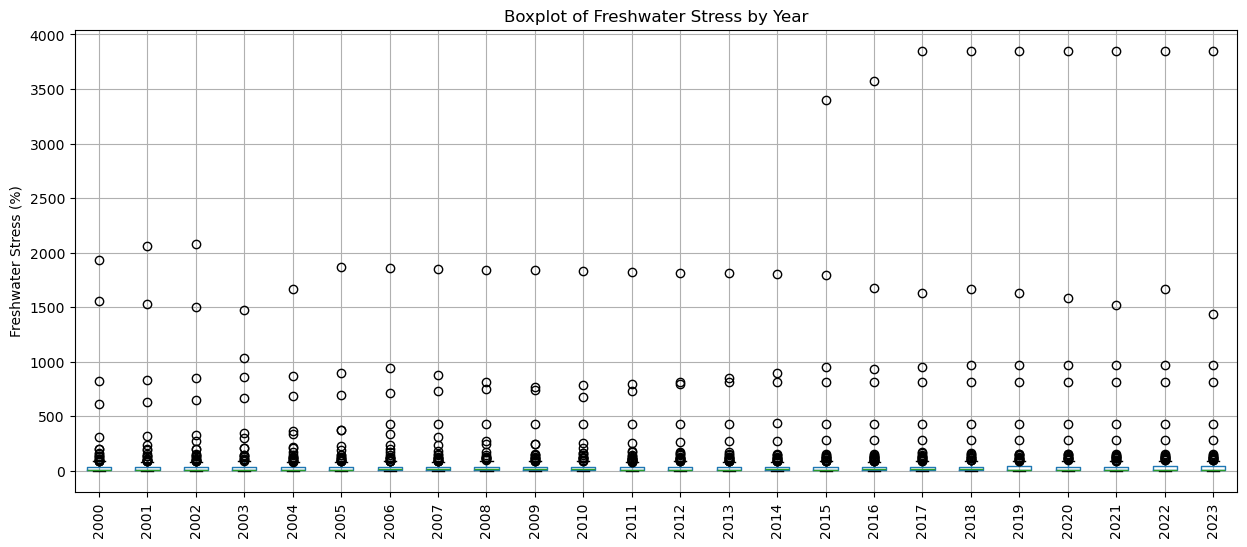

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

stress_df[years_2000_2023].boxplot()

plt.xticks(rotation=90)
plt.ylabel("Freshwater Stress (%)")
plt.title("Boxplot of Freshwater Stress by Year")

plt.show()

In [ ]:
stress_possible_outliers = []

for year in years_2000_2023:

    Q1 = stress_df[year].quantile(0.25)
    Q3 = stress_df[year].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = stress_df[
        (stress_df[year] < lower_bound) |
        (stress_df[year] > upper_bound)
    ][['GeoAreaName', year]].copy()

    # Rename value column
    outliers = outliers.rename(columns={year: 'FreshwaterStress'})

    # Add year column
    outliers['Year'] = year

    stress_possible_outliers.append(outliers)

stress_possible_outliers_df = pd.concat(stress_possible_outliers)

display(stress_possible_outliers_df)

,GeoAreaName,FreshwaterStress,Year
11,Bahrain,197.06,2000
12,Barbados,101.25,2000
14,Belgium,92.54,2000
56,Egypt,103.88,2000
86,Iraq,92.69,2000
...,...,...,...
179,Tunisia,97.05,2023
180,Turkmenistan,135.21,2023
184,United Arab Emirates,1437.33,2023
189,Uzbekistan,123.03,2023
